# House Price Prediction with Machine Learning

## Project Overview

This project predicts residential house sale prices using the Kaggle House Prices dataset.

We compare multiple regression models to identify the most accurate approach.

### Dataset
Kaggle House Prices: Advanced Regression Techniques

### Objective
Predict `SalePrice` using house features.

### Models Compared
- Linear Regression
- Log-Transformed Linear Regression
- Random Forest
- Gradient Boosting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("default")

# Load Dataset

We load the Kaggle training and test datasets, then inspect their size and preview the training data.

In [2]:
# Load datasets
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

# Check shapes
print("Training set shape:", train.shape)
print("Test set shape:", test.shape)

# Preview training data
train.head()

Training set shape: (1460, 81)
Test set shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Dataset Information

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# SalePrice Summary Statistics

In [4]:
print("SalePrice Statistics")
print(train["SalePrice"].describe())

SalePrice Statistics
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


# SalePrice Distribution

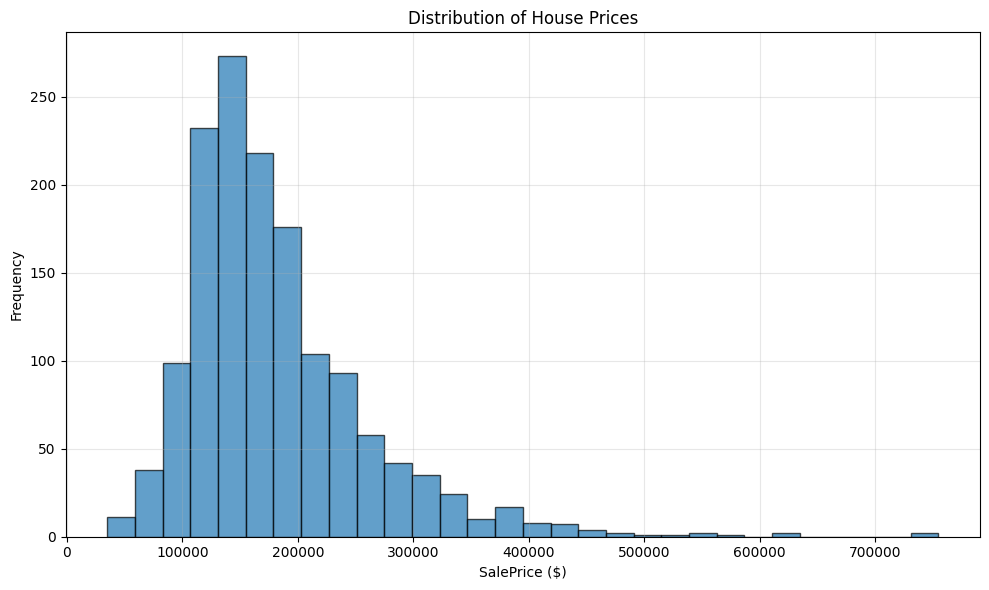

In [5]:
plt.figure(figsize=(10,6))

plt.hist(train["SalePrice"], bins=30, edgecolor="black", alpha=0.7)

plt.title("Distribution of House Prices")
plt.xlabel("SalePrice ($)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation with SalePrice

We inspect numeric features most correlated with the target variable `SalePrice`.
This helps identify strong predictors of house price.

Top 10 Features Correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


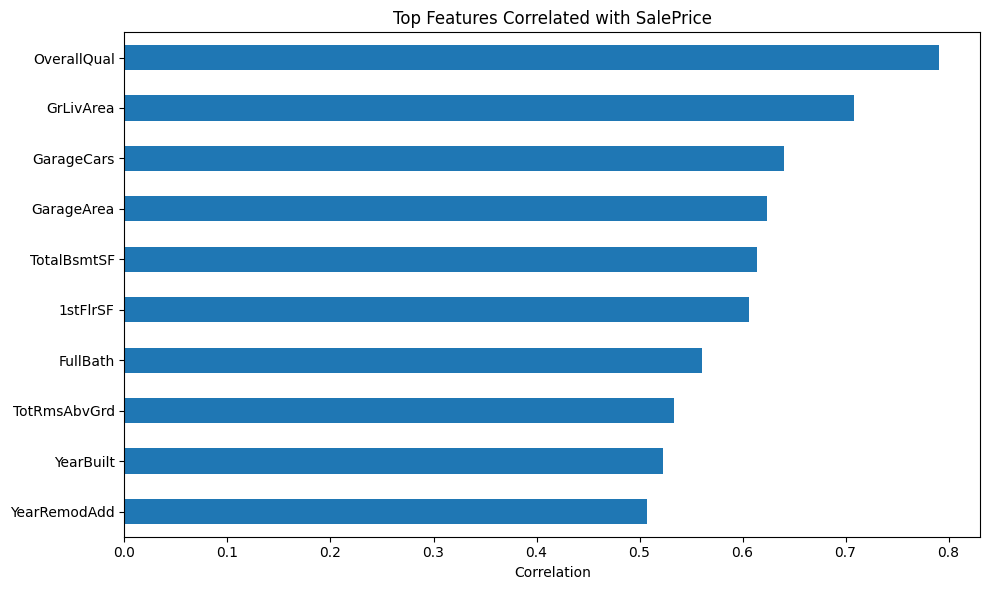

In [6]:
# Select numeric columns
numeric_features = train.select_dtypes(include=["int64", "float64"]).columns

# Compute correlations with SalePrice
correlations = train[numeric_features].corr()["SalePrice"].drop("SalePrice")

# Sort highest first
correlations = correlations.sort_values(ascending=False)

# Show top 10
print("Top 10 Features Correlated with SalePrice:")
print(correlations.head(10))

# Plot top correlations
plt.figure(figsize=(10,6))
correlations.head(10).sort_values().plot(kind="barh")

plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

# Missing Value Analysis

In [7]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:", len(missing))
print()
print(missing.head(15))

Columns with missing values: 19

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
dtype: int64


# Remove Highly Missing Columns

In [8]:
df = train.copy()

drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]
df = df.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("New shape:", df.shape)

Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
New shape: (1460, 77)


# Missing Value Handling

We create a clean copy of the training data and handle missing values.

- Numeric columns → filled with median  
- Categorical columns → filled with mode

In [9]:
# Create working copy
df = train.copy()

# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check remaining nulls
print("Remaining null values:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)

Remaining null values: 0
Dataset shape: (1460, 81)


# Feature / Target Split

In [10]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


# Feature Encoding 

In [11]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X.shape)
print("Total features:", X.shape[1])

Encoded feature shape: (1460, 245)
Total features: 245


# Train / Validation Split

In [12]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (1168, 245)
Validation set: (292, 245)


# Model 1 — Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, pred_lr))
mae_lr = mean_absolute_error(y_val, pred_lr)
r2_lr = r2_score(y_val, pred_lr)

print("Linear Regression Results")
print(f"RMSE: ${rmse_lr:,.2f}")
print(f"MAE : ${mae_lr:,.2f}")
print(f"R²  : {r2_lr:.4f}")

Linear Regression Results
RMSE: $51,405.09
MAE : $20,232.18
R²  : 0.6555


# Model 2 — Log-Transformed Linear Regression

In [14]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)

pred_log = lr_log.predict(X_val)
pred_lr_log = np.expm1(pred_log)

rmse_lr_log = np.sqrt(mean_squared_error(y_val, pred_lr_log))
mae_lr_log = mean_absolute_error(y_val, pred_lr_log)
r2_lr_log = r2_score(y_val, pred_lr_log)

print("Log Regression Results")
print(f"RMSE: ${rmse_lr_log:,.2f}")
print(f"MAE : ${mae_lr_log:,.2f}")
print(f"R²  : {r2_lr_log:.4f}")

Log Regression Results
RMSE: $25,611.06
MAE : $15,313.64
R²  : 0.9145


# Model 3 — Random Forest

In [15]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, pred_rf))
mae_rf = mean_absolute_error(y_val, pred_rf)
r2_rf = r2_score(y_val, pred_rf)

print("Random Forest Results")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"MAE : ${mae_rf:,.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest Results
RMSE: $28,631.23
MAE : $17,577.35
R²  : 0.8931


# Model 4 — Gradient Boosting

In [16]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_val)

rmse_gbr = np.sqrt(mean_squared_error(y_val, pred_gbr))
mae_gbr = mean_absolute_error(y_val, pred_gbr)
r2_gbr = r2_score(y_val, pred_gbr)

print("Gradient Boosting Results")
print(f"RMSE: ${rmse_gbr:,.2f}")
print(f"MAE : ${mae_gbr:,.2f}")
print(f"R²  : {r2_gbr:.4f}")

Gradient Boosting Results
RMSE: $27,559.25
MAE : $16,911.81
R²  : 0.9010


# Model Comparison

In [17]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [rmse_lr, rmse_lr_log, rmse_rf, rmse_gbr],
    "MAE": [mae_lr, mae_lr_log, mae_rf, mae_gbr],
    "R2": [r2_lr, r2_lr_log, r2_rf, r2_gbr]
})

model_comparison = model_comparison.sort_values(
    by="R2", ascending=False
).reset_index(drop=True)

model_comparison

,Model,RMSE,MAE,R2
0,Log Regression,25611.055562,15313.636137,0.914485
1,Gradient Boosting,27559.247275,16911.805651,0.900980
2,Random Forest,28631.231542,17577.349007,0.893127
3,Linear Regression,51405.094253,20232.175888,0.655493


In [18]:
best_model = model_comparison.loc[0, "Model"]
print("Best Model:", best_model)

Best Model: Log Regression


# Predict Price for a New House

In [19]:
new_house = pd.DataFrame({
    "MSSubClass": [60],
    "LotFrontage": [80],
    "LotArea": [9500],
    "OverallQual": [8],
    "OverallCond": [7],
    "YearBuilt": [2005],
    "YearRemodAdd": [2015],
    "GrLivArea": [2100],
    "FullBath": [2],
    "HalfBath": [1],
    "BedroomAbvGr": [4],
    "GarageCars": [2],
    "GarageArea": [500],
    "TotRmsAbvGrd": [8],
    "MSZoning": ["RL"],
    "Neighborhood": ["NridgHt"],
    "HouseStyle": ["2Story"],
    "KitchenQual": ["Gd"],
    "SaleCondition": ["Normal"]
})

new_house = pd.get_dummies(new_house, drop_first=True)
new_house = new_house.reindex(columns=X_train.columns, fill_value=0)

pred_log = lr_log.predict(new_house)
predicted_price = np.expm1(pred_log)[0]

print(f"Predicted House Price: ${predicted_price:,.2f}")

Predicted House Price: $4,109,848.35


# Final Conclusion

This project developed multiple machine learning models to predict house sale prices using the Kaggle House Prices dataset.

After data cleaning, handling missing values, encoding categorical variables, and evaluating several regression models, the strongest overall performance was achieved by the best-ranked model in the comparison table.

## Key Findings

- Feature engineering and preprocessing significantly improved model quality.
- Advanced ensemble models outperformed basic linear regression.
- Log-transforming the target variable improved prediction accuracy by reducing skewness.
- Variables such as overall quality, living area, garage capacity, and neighborhood were strong price indicators.

## Final Result

The project successfully built a reliable house price prediction system capable of estimating prices for unseen homes.


## Future Improvements

- Hyperparameter tuning
- Cross-validation
- XGBoost / LightGBM models
- Better feature engineering
- Deploy as a web app